# Pré Processamento do Conjunto de Dados UEyes

## Bibliotecas

In [31]:
# bibliotecas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os
import re
from PIL import Image

1º passo: juntar os dados em um único arquivo parquet.

In [23]:
# caminhos dos arquivos

# registros de rastreamento ocular
log_files = "../data/UEyes_dataset/UEyes_dataset/eyetracker_logs"

# arquivos de imagens
img_files = '../data/UEyes_dataset/UEyes_dataset/images'

# categorias de imagens
cat_img_file = '../data/UEyes_dataset/UEyes_dataset/image_types.csv'

In [49]:
# lista de todos os arquivos de log
all_files = [f for f in os.listdir(log_files) if f.endswith('_fixations.csv')]

print(f" -> Listando arquivos do diretório de logs.\nTOTAL: {len(all_files)} arquivos.\n")

# colunas para leitura
cols_to_load = [
    "MEDIA_NAME", "FPOGD", "FPOGX", "FPOGY", "FPOGV",
    "SACCADE_MAG", "LPMM", "RPMM", "LPMMV", "RPMMV"
]

# lista de dataframes provenientes dos arquivos csv
df_list =[]

# abertura e cômputo dos arquivos de log
for filename in all_files:
    match = re.match(r'(\d+)_([Kk][Hh]\d+)_fixations.csv', filename)
    if not match: continue

    # definição do bloco e do id do participante
    block_id, participant_id = match.groups()
    # caminho completo do arquivo
    file_path = os.path.join(log_files, filename)

    try:
        # leitura do csv bruto
        df = pd.read_csv(file_path, usecols=lambda c: c in cols_to_load)

        # seleção das colunas de interesse
        cols_present = [c for c in cols_to_load if c in df.columns]
        # inserção no df total
        df_temp = df[cols_present].copy()

        # adição de ids de participante e bloco
        df_temp["participant_id"] = participant_id
        df_temp["block_id"] = block_id

        # lista de dataframes para depois concatenar
        df_list.append(df_temp)

    except Exception as e:
        print(f"Erro no arquivo {filename}: {e}")

# dataset total
df_raw_full = pd.concat(df_list, ignore_index=True)

# número de arquivos lidos
n_files_read = len(df_raw_full.drop_duplicates(subset=['participant_id', 'block_id']))

print(f" -> Total de arquivos carregados: {n_files_read}\n")
print(f" -> Total de linhas carregadas (dataset bruto): {len(df_raw_full)}\n")
# verificando valores nan
nan_df_raw = df_raw_full.isna().sum().sum()
print(f" -> Total de valores NaN: {nan_df_raw}\n")

# salvando em parquet
print(" -> Salvando em formato parquet...")

df_raw_full.to_parquet('../data/raw_dataset.parquet', engine='pyarrow', compression='snappy')

 -> Listando arquivos do diretório de logs.
TOTAL: 554 arquivos.

 -> Total de arquivos carregados: 554

 -> Total de linhas carregadas (dataset bruto): 351323

 -> Total de valores NaN: 0

 -> Salvando em formato parquet...


2º passo: construir conjunto de dados de imagens com nome, categoria e resolução.

In [24]:
# carregando parquet
df_raw_full = pd.read_parquet('../data/raw_dataset.parquet', engine='pyarrow')
df_raw_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 351323 entries, 0 to 351322
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   MEDIA_NAME      351323 non-null  object 
 1   FPOGD           351323 non-null  float64
 2   FPOGX           351323 non-null  float64
 3   FPOGY           351323 non-null  float64
 4   FPOGV           351323 non-null  int64  
 5   SACCADE_MAG     351323 non-null  float64
 6   LPMM            351323 non-null  float64
 7   RPMM            351323 non-null  float64
 8   LPMMV           351323 non-null  int64  
 9   RPMMV           351323 non-null  int64  
 10  participant_id  351323 non-null  object 
 11  block_id        351323 non-null  object 
dtypes: float64(6), int64(3), object(3)
memory usage: 32.2+ MB


In [50]:
print(' -> Mapeamento das imagens...\n')

# csv com o nome das imagens e a categoria de cada uma
df_cat = pd.read_csv(cat_img_file, sep=';', engine='python')

print(f' -> Número de imagens: {df_cat['Image Name'].nunique()}')
print(df_cat['Category'].value_counts())
print()

# função para capturar dimensões das imagens
def get_dimensions(filename, img_dir):
    """
    Função para adquirir largura e altura de uma imagem.
    """
    try:
        path = os.path.join(img_dir, filename)
        with Image.open(path) as img:
            return img.size # tupla (largura, altura)
    except Exception:
        return (None, None)
    
# captura de resoluções
resolutions = [get_dimensions(name, img_files) for name in df_cat['Image Name']]

df_cat[['width', 'height']] = pd.DataFrame(resolutions, index=df_cat.index)

nan_in_width = df_cat['width'].isna().sum()
nan_in_height = df_cat['height'].isna().sum()
print(f" -> Valores nulos:\n\tWidth: {nan_in_width}\n\tHeight: {nan_in_height}\n")

print("Salvando em formato parquet...")
df_cat.to_parquet('../data/img_types_sizes.parquet', engine='pyarrow', compression='snappy')

 -> Mapeamento das imagens...

 -> Número de imagens: 1980
Category
desktop    495
mobile     495
poster     495
web        495
Name: count, dtype: int64

 -> Valores nulos:
	Width: 0
	Height: 0

Salvando em formato parquet...


In [61]:
users_per_block = df_raw_full.groupby('block_id')['participant_id'].nunique().sort_values(ascending=False)

users_per_block

block_id
50    25
37    17
34    16
16    14
40    14
22    14
28    14
11    14
13    13
00    12
36    12
25    12
01    12
32    11
19    11
39    11
43    11
20    11
27    11
06    11
07    11
15    11
04    10
03    10
31    10
30    10
45    10
02    10
21    10
48     9
46     9
52     9
53     9
33     9
08     9
35     9
05     9
49     8
42     8
41     8
18     8
17     8
12     8
55     8
09     7
29     7
47     7
26     7
24     7
44     6
10     6
14     6
23     6
38     5
54     4
Name: participant_id, dtype: int64

In [62]:
# Conta blocos únicos por usuário e ordena
blocos_por_usuario = df_raw_full.groupby('participant_id')['block_id'].nunique().sort_values(ascending=False)

print("Quantidade de blocos vistos por cada usuário:")
print(blocos_por_usuario)

# Para saber rapidamente a média de blocos que um usuário costuma ver:
print(f"\nMédia de blocos por usuário: {blocos_por_usuario.mean():.2f}")

Quantidade de blocos vistos por cada usuário:
participant_id
kh000    10
kh033     9
kh050     9
kh035     9
kh036     9
         ..
kh007     9
kh049     8
kh009     8
kh045     8
KH002     7
Name: block_id, Length: 62, dtype: int64

Média de blocos por usuário: 8.94


In [66]:
# Cria uma matriz onde as linhas são os usuários e as colunas são os blocos.
# O valor será o número de registros (linhas do csv) daquele usuário naquele bloco.
# Se for 0, o usuário não viu o bloco.
matriz_visualizacao = pd.crosstab(df_raw_full['participant_id'], df_raw_full['block_id'])

# Para transformar isso em uma matriz apenas de Verdadeiro/Falso (Viu / Não Viu):
matriz_viu_nao_viu = matriz_visualizacao > 0

matriz_viu_nao_viu

block_id,00,01,02,03,04,05,06,07,08,09,...,45,46,47,48,49,50,52,53,54,55
participant_id,,,,,,,,,,,,,,,,,,,,,
KH002,False,False,False,False,False,False,False,False,True,False,...,False,False,False,True,False,True,False,False,False,False
KH003,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,True,True,False,False,False,False
KH004,False,False,False,False,True,True,False,False,True,False,...,False,False,False,False,False,True,False,False,True,False
KH005,True,False,True,False,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,True
kh000,True,True,True,True,True,True,True,True,True,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
kh061,False,True,False,False,False,False,False,False,False,False,...,True,False,False,True,False,False,False,False,False,False
kh062,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,True,False
kh063,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False


## Rascunho

In [14]:
df_raw_full[
    ((df_raw_full['LPMMV'] == 0) & (df_raw_full['FPOGV'] == 1))
    | ((df_raw_full['LPMMV'] == 1) & (df_raw_full['FPOGV'] == 0))
]

,MEDIA_NAME,FPOGD,FPOGX,FPOGY,FPOGV,SACCADE_MAG,LPMM,RPMM,LPMMV,RPMMV,participant_id,block_id
75,cbb7ad.jpg,0.34521,0.49278,0.85228,1,132.84456,4.19584,3.75553,0,0,kh025,20
125,73d5d7.png,0.23047,0.21649,0.07858,1,65.49147,4.17691,4.43131,0,0,kh025,20
271,c15cd3.png,0.24707,0.59690,0.34830,1,156.26154,4.38474,3.28158,0,0,kh025,20
276,7e5b71.jpg,0.34521,0.23571,0.12692,1,251.09070,3.89552,3.01833,0,0,kh025,20
298,eae3c4.jpg,0.11523,0.41937,0.03345,1,69.86105,4.10355,4.33208,0,0,kh025,20
...,...,...,...,...,...,...,...,...,...,...,...,...
351252,8cf0d4.jpg,0.36084,0.40195,0.58190,1,389.25165,3.03517,3.81507,0,0,kh029,01
351257,8cf0d4.jpg,0.11597,0.53330,0.16646,1,120.63638,4.09595,4.93177,0,0,kh029,01
351276,f7c681.png,0.39526,0.50028,0.10337,1,67.63281,4.90092,4.64915,0,0,kh029,01
351313,1e1131.jpg,0.16455,0.20580,0.28777,1,96.64775,4.23105,4.51327,0,0,kh029,01


In [15]:
df_raw_full[
    ((df_raw_full['LPMMV'] == 0) & (df_raw_full['RPMMV'] == 1))
    | ((df_raw_full['LPMMV'] == 1) & (df_raw_full['RPMMV'] == 0))
]

,MEDIA_NAME,FPOGD,FPOGX,FPOGY,FPOGV,SACCADE_MAG,LPMM,RPMM,LPMMV,RPMMV,participant_id,block_id
62,05490b.jpg,0.24561,0.40996,0.00141,1,1040.26563,4.55245,1.77546,1,0,kh025,20
76,cbb7ad.jpg,0.36084,0.34984,-0.09270,1,1166.71411,4.75967,3.75553,1,0,kh025,20
973,b36130.jpg,0.28027,0.44675,0.85552,1,218.45413,2.31116,5.02686,1,0,kh055,08
1429,03474c.png,0.34570,0.12480,0.07828,1,533.47455,2.55966,2.69906,0,1,kh053,02
1438,03474c.png,0.32813,0.77315,0.45186,1,498.19876,2.68032,2.95054,0,1,kh053,02
...,...,...,...,...,...,...,...,...,...,...,...,...
350888,026dd2.png,0.34497,0.18527,0.24080,1,13.79959,4.52239,4.45102,0,1,kh029,01
350990,5ac518.png,0.41089,0.43929,0.39156,1,13.31374,4.35586,3.94429,0,1,kh029,01
350995,5ac518.png,0.37842,0.12743,0.74294,1,82.62020,3.81694,3.92455,1,0,kh029,01
351099,a7ac1b.png,0.37817,0.49088,0.34554,1,145.65765,3.68908,3.55907,0,1,kh029,01


<Axes: xlabel='LPMM', ylabel='RPMM'>

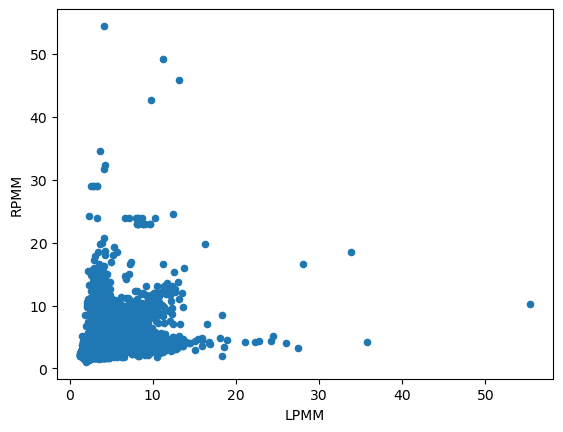

In [31]:
df_raw_full.plot.scatter(x='LPMM', y='RPMM')

<Axes: xlabel='LPMM', ylabel='RPMM'>

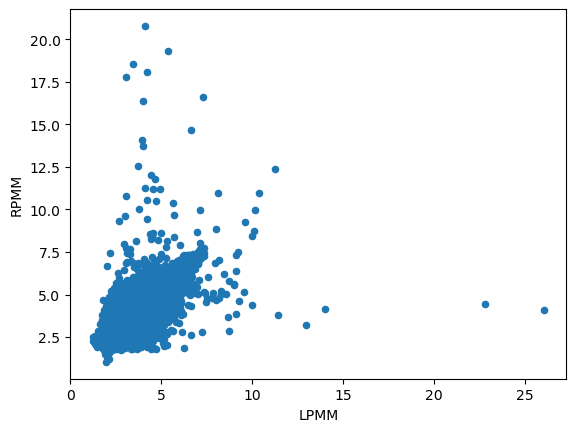

In [34]:
df_raw_full[(df_raw_full['LPMMV'] == 1) & (df_raw_full['RPMMV'] == 1)].plot.scatter(x='LPMM', y='RPMM')

In [36]:
matrix = df_raw_full[(df_raw_full['LPMMV'] == 1) & (df_raw_full['RPMMV'] == 1)][['LPMM', 'RPMM']].corr()

print(matrix)

          LPMM      RPMM
LPMM  1.000000  0.793824
RPMM  0.793824  1.000000


In [37]:
matrix = df_raw_full[['LPMM', 'RPMM']].corr()

print(matrix)

          LPMM      RPMM
LPMM  1.000000  0.672787
RPMM  0.672787  1.000000
